## Simple Linear Regression Ex 2: Salary Data

In this exercise we will repeat our analysis from the previous exercise this time using data to predict an employee's salary from their years of experience. This time we will also use the scikit-learn pacakge to perform the analysis.

First we import our required packages and dataset into the notebook.

In [8]:
import pandas as pd
import matplotlib.pyplot as plot
import statsmodels.api as stats
import numpy as np

In [9]:
salary_df = pd.read_csv("Salary_Data.csv")

### Assessing the Data

We again take a look at the dimensions of the data.

In [4]:
salary_df.shape

(30, 2)

In [5]:
salary_df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


### Visualising the Data

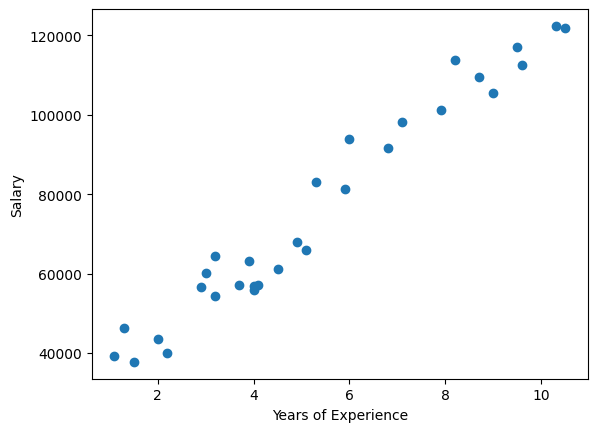

In [6]:
plot.scatter(salary_df["YearsExperience"],salary_df["Salary"])
plot.xlabel("Years of Experience")
plot.ylabel("Salary")
plot.show()

### Fitting the Linear Regression Model

We separate the independent variable, YearsExperience and the target variable, Salary before fitting our model.

In [7]:
Y_salary = salary_df.Salary
X_salary = stats.add_constant(salary_df.YearsExperience)


In [13]:
model_salary = stats.OLS(Y_salary, X_salary )
results_salary = model_salary.fit()
results_salary
results_salary.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Salary   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     622.5
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           1.14e-20
Time:                        14:25:23   Log-Likelihood:                -301.44
No. Observations:                  30   AIC:                             606.9
Df Residuals:                      28   BIC:                             609.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            2.579e+04   2273.053     11.347      0.000    2.11e+04    3.04e+04
YearsExperience  9449.9623    378.755     24.950      0.000    8674.119    1.02e+04
==============================================================================
Omnibus:                        2.140   Durbin-Watson:                   1.648
Prob(Omnibus):                  0.343   Jarque-Bera (JB):                1.569
Skew:                           0.363   Prob(JB):                        0.456
Kurtosis:                       2.147   Cond. No.                         13.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Finally we can write out our results and plot these.

In [17]:
intercept_salary = results_salary.params.iloc[0]
experience_coeff = results_salary.params.iloc[1]
ssr_salary = results_salary.ssr

print('The intercept value is {:.3f}'.format(intercept_salary))
print('The coefficient (slope) for the years of experience independent variable is {:.3f}'.format(experience_coeff))
print('The sum of square residuals is {:.1f}'.format(ssr_salary))

The intercept value is 25792.200
The coefficient (slope) for the years of experience independent variable is 9449.962
The sum of square residuals is 938128551.7


### Plotting Results

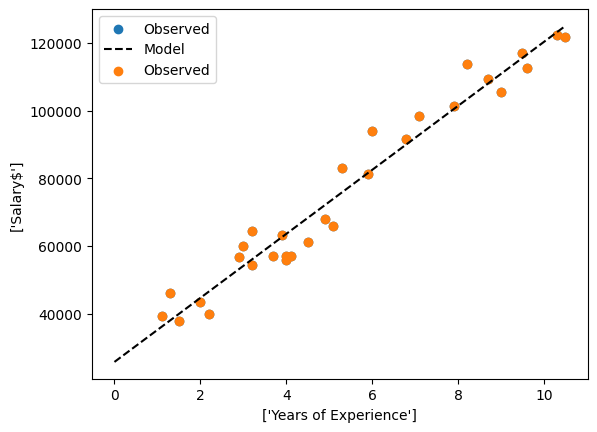

In [25]:
# Observaation
plot.scatter(salary_df.YearsExperience, salary_df.Salary, label = "Observed")

# Line of Best Fit
x_synthetic = np.linspace(0,salary_df.YearsExperience.max(), 50)
y_pred_salary = experience_coeff*x_synthetic + intercept_salary

plot.plot(x_synthetic, y_pred_salary, color='k', ls='--', label='Model')

plot.scatter(salary_df.YearsExperience, salary_df.Salary, label='Observed')

# Plot the Chart
plot.xlabel(["Years of Experience"])
plot.ylabel(["Salary$"])
plot.legend()

plot.show()

## Scikit-Learn 

We will now perform the same process, this time using the Scikit-learn package. At this stage we only need to import the LinearRegression class from the linear_model module within the package.

In [1]:
%pip install sklearn-linear


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement sklearn-linear (from versions: none)
ERROR: No matching distribution found for sklearn-linear


In [1]:
from sklearn.linear_model import LinearRegression

We will reset our independent variable X and target variable Y as we don't need a constant column here as we did using statsmodels.

In [10]:

X_salary = salary_df["YearsExperience"]
Y_salary = salary_df["Salary"]

We do need to reshape our independent variable to have a the correct format for scikit-learn however as the LinearRegression class works on 2D X arrays but here we only have a single independent variable. We do this by first converting the pandas series to a numpy array using the [series.values](https://pandas.pydata.org/docs/reference/api/pandas.Series.values.html) method before using the [ndarray.reshape](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.reshape.html#numpy.ndarray.reshape) method in the following way to reshape our array to the desired form. 

In [12]:
X_salary.shape

(30,)

In [13]:
X_salary = X_salary.values.reshape(-1, 1)

In [14]:
X_salary.shape

(30, 1)

We now need to initialize an instance of the [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) class, which we name regressor. We can then simply call the .fit() method with our independent variable and target variable as arguments to fit our model. Our fully fitted model is then contained within the regressor class instance. 

In [15]:
regressor = LinearRegression()  
regressor.fit(X_salary, Y_salary)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9449.96]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.579e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[15.28]


We can obtain our intercept and slope from the class attributes .intercept_ and .coef_. We need to manually calculate our sum of square error using the .predict() method to get our predicted Y values from our X values. We then subtract these from their observed values, square them and sum all of them using the function [np.sum](https://numpy.org/doc/stable/reference/generated/numpy.sum.html).
 

In [16]:
sk_intercept_salary = regressor.intercept_
sk_experience_coeff = regressor.coef_[0]
sk_ssr_salary = np.sum((Y_salary-regressor.predict(X_salary))**2)

In [17]:
print(sk_intercept_salary)
print(sk_experience_coeff)

25792.20019866871
9449.962321455074


In [18]:
print('Using Scikit-learn...')
print('The intercept value is {:.3f}'.format(sk_intercept_salary))
print('The coefficient (slope) for the years of experience independent variable is {:.3f}'.format(sk_experience_coeff))
print('The sum of square residuals is {:.1f}'.format(sk_ssr_salary))

Using Scikit-learn...
The intercept value is 25792.200
The coefficient (slope) for the years of experience independent variable is 9449.962
The sum of square residuals is 938128551.7


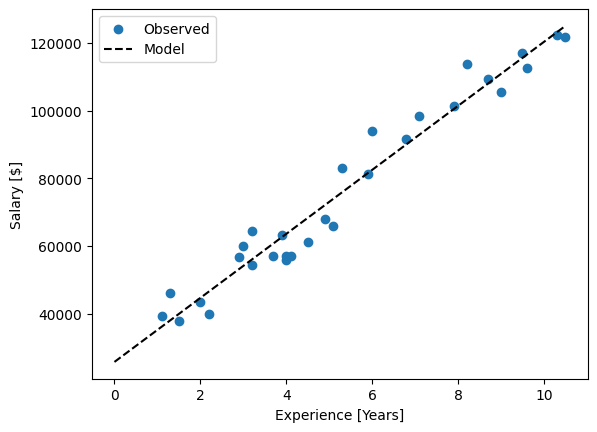

In [19]:
x_synthetic = np.linspace(0,salary_df.YearsExperience.max(), 50)
sk_y_pred_salary = sk_experience_coeff*x_synthetic + sk_intercept_salary
plot.scatter(salary_df.YearsExperience, salary_df.Salary, label='Observed')
plot.plot(x_synthetic, sk_y_pred_salary, color='k', ls='--', label='Model')
plot.xlabel('Experience [Years]')
plot.ylabel('Salary [$]')
plot.legend()
plot.show()

These are the same results as we got using the statsmodels package which is what we would expect since linear regression simply follows the ordinary least squares algorithm we have dicussed in previous lessons.